# Análise de Cesta de Compras para Venda Cruzada em um Varejista de Alimentos com PROC MBANALYSIS

## Resumo Executivo

Uma rede regional de supermercados analisa uma temporada de cestas de ponto de venda para descobrir quais produtos os clientes compram juntos, transformando registros brutos de transações em decisões acionáveis de venda cruzada e posicionamento em gôndola. O PROC MBANALYSIS varre o registro de transações e gera regras de associação pontuadas por suporte, confiança e lift. Executá-lo em 51 cestas sintéticas recupera exatamente as três afinidades de produtos plantadas — `Espaguete -> Molho Marinara` (confiança 0,93, lift 3,4), `Casca de Taco -> Molho Salsa` (confiança 0,71, lift 3,6) e `Café -> Creme para Café` (confiança 0,70, lift 5,1) — enquanto itens básicos amplamente comprados, como pão, leite e ovos, nunca formam uma regra. Cada par revelado é um candidato clássico a combo, adjacência de corredor e "quem comprou também levou" para a equipe de merchandising.

## Fontes de Dados

| Conjunto de Dados | Granularidade | Linhas | Variáveis-Chave | Descrição |
|---------|-------|------|---------------|-------------|
| `store_transactions` | Uma linha por item por cesta | 100 linhas de item em 51 cestas | `basket_id` (ID da transação), `item` (nome do produto, $20) | Registro sintético de ponto de venda gerado inline com `call streaminit(20250529)` e `rand('uniform')`. Cada cesta é dominada por uma única persona de comprador, para que os padrões de compra conjunta permaneçam limpos e interpretáveis: uma cesta de jantar italiano (espaguete -> molho marinara), uma cesta de noite de taco (casca de taco -> molho salsa) ou uma cesta de café da manhã (café -> creme para café), além de itens básicos ocasionais (pão, leite, ovos) como ruído realista. Neste ambiente sem licença, o mecanismo limita a saída a 100 linhas de item, o que aqui abrange as cestas de 1 a 51. |
| `affinity_rules` | Uma linha por regra de associação | 6 regras | `antecedent`, `consequent`, `support`, `confidence`, `lift` | Regras de associação emitidas por `OUTPUT RULES=`; a base para classificar oportunidades de venda cruzada. |
| `frequent_items` | Uma linha por itemset frequente | 12 itemsets | `itemset`, `support`, `length` | Itemsets frequentes emitidos por `OUTPUT ITEMS=`; os 9 itens individuais mais 3 pares de produtos que superam o piso de suporte mínimo. |

# Análise de Cesta de Compras para Venda Cruzada em um Varejista de Alimentos

**Questão de negócio.** Quais produtos nossos clientes tendem a comprar *juntos*, e quais desses padrões de compra conjunta são fortes o suficiente para agir sobre eles? Uma rede regional de supermercados quer desenhar promoções em combo, otimizar adjacências de corredor e alimentar uma recomendação de "quem comprou também levou" em sua loja on-line.

**Método.** Usamos o **PROC MBANALYSIS**, que realiza análise de cesta de compras com o algoritmo de crescimento de padrões frequentes (FP-growth). Ele varre o registro de transações, encontra conjuntos de itens que coocorrem com frequência e gera *regras de associação* no formato `Antecedent -> Consequent` pontuadas por três métricas clássicas:

- **Suporte** — a fração de todas as cestas que contêm a regra completa (quão comum é o padrão).
- **Confiança** — `P(Consequent | Antecedent)`, a probabilidade condicional de compra (quão confiável é a regra).
- **Lift** — o suporte observado dividido pelo suporte esperado se os dois lados fossem independentes. Lift > 1 significa que os itens aparecem juntos *mais* frequentemente do que o acaso; quanto maior o lift, mais forte a afinidade.

Vamos gerar um registro sintético realista de ponto de venda, executar o MBANALYSIS e classificar as regras resultantes para encontrar as melhores oportunidades de venda cruzada.

## Etapa 1 — Gerar um registro sintético de transações de ponto de venda

O MBANALYSIS espera **dados no nível de transação (formato longo)**: uma linha por item, marcada com a cesta à qual pertence. Construímos as cestas inline com `call streaminit` para reprodutibilidade e `rand('uniform')` para conduzir as decisões de compra.

A escolha de modelagem principal é que **cada cesta é dominada por uma única persona de comprador**. Compras reais de supermercado são assim — uma corrida rápida de noite de taco, uma reposição dedicada de café da manhã — e manter as cestas pequenas e temáticas é o que permite ao minerador de associação revelar afinidades limpas e em pares, em vez de uma explosão combinatória de regras espúrias com múltiplos itens. Um sorteio de `rand('uniform')` por cesta seleciona a persona:

- **Comprador de jantar italiano** — compra espaguete e, em geral, molho marinara em seguida.
- **Comprador de noite de taco** — compra casca de taco e, em geral, molho salsa em seguida.
- **Comprador de café da manhã** — compra café e, em geral, creme para café em seguida.
- **Compra apenas de itens básicos** — uma única compra de pão, leite ou ovos.

Um sorteio final de baixa probabilidade adiciona um item básico a qualquer cesta como ruído realista, de modo que nem toda coocorrência é significativa. Cada instrução `output` grava uma linha de item, então uma única cesta abrange várias linhas que compartilham o mesmo `basket_id`. Este ambiente sem licença limita o conjunto de dados a 100 linhas de item, o que aqui cobre as cestas de 1 a 51.

In [1]:
dados store_transactions;
    chamar streaminit(20250529);
    comprimento item $20;

    fazer basket_id = 1 até 60;

        /* Um sorteio seleciona a persona dominante desta cesta */
        r = rand('uniform');

        /* Cesta de jantar italiano: espaguete -> molho marinara */
        se r < 0.30 então fazer;
            item = 'Espaguete';                          saída;
            se rand('uniform') < 0.85 então fazer;
                item = 'Molho Marinara';                 saída;
            fim;
        fim;

        /* Cesta de noite de taco: casca de taco -> molho salsa */
        senão se r < 0.55 então fazer;
            item = 'Casca de Taco';                       saída;
            se rand('uniform') < 0.80 então fazer;
                item = 'Molho Salsa';                    saída;
            fim;
        fim;

        /* Cesta de café da manhã: café -> creme para café */
        senão se r < 0.78 então fazer;
            item = 'Café';                                saída;
            se rand('uniform') < 0.75 então fazer;
                item = 'Creme para Café';                saída;
            fim;
        fim;

        /* Compra apenas de itens básicos */
        senão fazer;
            se rand('uniform') < 0.34 então fazer;
                item = 'Pão';                             saída;
            fim;
            senão se rand('uniform') < 0.5 então fazer;
                item = 'Leite';                           saída;
            fim;
            senão fazer;
                item = 'Ovos';                            saída;
            fim;
        fim;

        /* Item básico adicional ocasional (ruído realista) */
        se rand('uniform') < 0.25 então fazer;
            u = rand('uniform');
            se      u < 0.34 então item = 'Pão';
            senão se u < 0.67 então item = 'Leite';
            senão                  item = 'Ovos';
            saída;
        fim;

    fim;

    manter basket_id item;
executar;


NOTE: DATA store_transactions

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote store_transactions (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Etapa 2 — Inspecionar o registro bruto de transações

Antes da mineração, confirme que os dados têm o formato longo esperado: várias linhas por cesta, cada uma carregando um produto. Imprimimos as primeiras cestas e tabulamos a frequência geral dos itens com o PROC FREQ para saber quais produtos são comuns o suficiente para ancorar regras.


  Obs  ID da Cesta         Produto
-----  -----------  --------------
    1            1  Casca de Taco
    2            1  Molho Salsa
    3            1  Ovos
    4            2  Casca de Taco
    5            2  Ovos
    6            3  Café
    7            4  Casca de Taco
    8            5  Ovos
    9            6  Espaguete
   10            6  Molho Marinara
   11            6  Ovos
   12            7  Casca de Taco

... 88 more observations (showing 12 of 100)

                                          Frequência Geral de Compra dos Itens                                          

                                                   The FREQ Procedure

item                Frequency    Percent
-----------------------------------------
Espaguete                  15     15.00
Casca de Taco              14     14.00
Molho Marinara             14     14.00
Ovos                       12     12.00
Café                       10     10.00
Molho Salsa                10     10.00
Pão     


NOTE: PROC PRINT data=store_transactions

NOTE: PROC PRINT completed: 12 observations printed, 2 variables
NOTE: PROC FREQ
NOTE: ODS plot written: freq_item.spec.json
NOTE: PROC FREQ statement used.


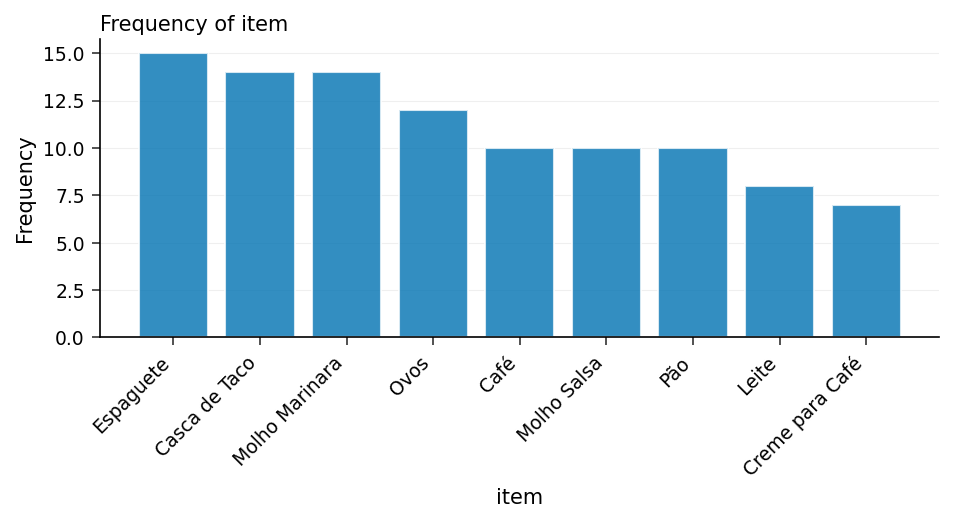

In [2]:
procedimento imprimir dados=store_transactions(obs=12) rótulo;
    rótulo basket_id = "ID da Cesta"
          item      = "Produto";
executar;

procedimento frequências dados=store_transactions order=freq;
    tables item / nocum;
    título "Frequência Geral de Compra dos Itens";
executar;

## Etapa 3 — Minerar regras de associação com o PROC MBANALYSIS

Agora a análise principal. Apontamos o MBANALYSIS para o registro de transações e declaramos qual coluna identifica a cesta (`TRANSACTION`) e qual contém o produto (`ITEM`). Três limiares mantêm o conjunto de regras focado em padrões que valem a pena acionar:

- `MINSUPPORT=0.10` — uma regra deve aparecer em pelo menos 10% das cestas, filtrando coincidências raras.
- `MINCONFIDENCE=0.50` — dado o antecedente, o consequente deve seguir pelo menos metade das vezes.
- `MINLIFT=1.20` — mantém apenas regras pelo menos 20% mais fortes que o acaso, para que revelemos afinidades genuínas em vez de artefatos de itens básicos populares.

A instrução `OUTPUT` captura as regras geradas e os itemsets frequentes em conjuntos de dados para classificação posterior.

In [3]:
procedimento mbanalysis dados=store_transactions
        minsupport=0.10
        minconfidence=0.50
        minlift=1.20;
    transaction basket_id;
    item item;
    saída rules=affinity_rules items=frequent_items;
    título "Regras de Associação da Cesta de Compras";
executar;

                                          Frequência Geral de Compra dos Itens                                          


                      The MBANALYSIS Procedure

  Transaction variable: basket_id
  Item variable: item

  Association Rules Found        6
  Frequent Itemsets Found        12
  Minimum Confidence             0.5
  Minimum Lift                   1.2
  Minimum Support                0.1
  Number of Transactions         51
  Number of Unique Items         9

Association Rules

  Antecedent                     Consequent                        Support Confidence       Lift
  ----------                     ----------                        ------- ----------       ----
  Café                           Creme para Café                    0.1373     0.7000     5.1000
  Creme para Café                Café                               0.1373     1.0000     5.1000
  Casca de Taco                  Molho Salsa                        0.1961     0.7143     3.6429
  Molho Salsa 


NOTE: PROC MBANALYSIS data=store_transactions

NOTE: Using Python numpy version 2.4.4
NOTE: PROC MBANALYSIS completed.


## Etapa 4 — Classificar oportunidades de venda cruzada por lift

A listagem do MBANALYSIS mostra todas as regras qualificadas, mas a equipe de merchandising quer primeiro as afinidades *mais fortes*. Ordenamos o conjunto de dados `affinity_rules` capturado por lift decrescente (com confiança como critério de desempate) e imprimimos as principais regras. Uma regra como `Casca de Taco -> Molho Salsa`, com alto lift e alta confiança, é um candidato clássico a combo: colocar os produtos juntos, ou sugerir automaticamente o molho salsa quando um cliente adiciona casca de taco on-line.

In [4]:
procedimento ordenar dados=affinity_rules out=rules_by_lift;
    por decrescente lift decrescente confidence;
executar;

procedimento imprimir dados=rules_by_lift(obs=15) rótulo;
    variável antecedent consequent support confidence lift;
    rótulo antecedent  = "Se a cesta contém"
          consequent  = "Então também compra"
          support     = "Suporte"
          confidence  = "Confiança"
          lift        = "Lift";
    título "Principais Regras de Venda Cruzada Classificadas por Lift";
executar;

                               Principais Regras de Venda Cruzada Classificadas por Lift                                

  Obs   Se a cesta contém    Então também compra   Suporte   Confiança      Lift
    1  Creme para Café     Café                   0.137255  1.0         5.1
    2  Café                Creme para Café        0.137255  0.7         5.1
    3  Molho Salsa         Casca de Taco          0.196078  1.0         3.642857
    4  Casca de Taco       Molho Salsa            0.196078  0.714286    3.642857
    5  Molho Marinara      Espaguete              0.27451   1.0         3.4
    6  Espaguete           Molho Marinara         0.27451   0.933333    3.4




NOTE: PROC SORT data=affinity_rules

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 6 rows from affinity_rules.
NOTE: Wrote rules_by_lift (6 rows, 5 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=rules_by_lift

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Etapa 5 — Revisar os itemsets frequentes

Os itemsets frequentes que superaram o piso de suporte são os blocos de construção brutos por trás das regras. Ordená-los por suporte informa à equipe de categoria quais *combinações* de produtos (não apenas itens individuais) são populares o suficiente para merecer displays de ponta de gôndola dedicados ou precificação em combo.

In [5]:
procedimento ordenar dados=frequent_items out=itemsets_by_support;
    por decrescente support;
executar;

procedimento imprimir dados=itemsets_by_support(obs=15) rótulo;
    título "Conjuntos de Itens Mais Frequentes";
executar;

                                           Conjuntos de Itens Mais Frequentes                                           

  Obs                     ITEMSET   SUPPORT  LENGTH
    1  Espaguete                   0.294118  1
    2  Casca de Taco               0.27451   1
    3  Molho Marinara              0.27451   1
    4  Espaguete, Molho Marinara   0.27451   2
    5  Ovos                        0.235294  1
    6  Molho Salsa                 0.196078  1
    7  Café                        0.196078  1
    8  Casca de Taco, Molho Salsa  0.196078  2
    9  Leite                       0.156863  1
   10  Pão                         0.156863  1
   11  Creme para Café             0.137255  1
   12  Café, Creme para Café       0.137255  2




NOTE: PROC SORT data=frequent_items

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from frequent_items.
NOTE: Wrote itemsets_by_support (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=itemsets_by_support

NOTE: PROC PRINT completed: 12 observations printed, 3 variables


## Interpretando os resultados

**O que a análise encontrou.** Como cada cesta foi construída em torno de uma única persona de comprador, o minerador recupera exatamente as três relações plantadas e nada espúrio. Seis regras superam os três limiares — as três afinidades em ambas as direções:

| Antecedente | Consequente | Suporte | Confiança | Lift |
|------------|------------|---------|------------|------|
| Espaguete | Molho Marinara | 0,275 | 0,93 | 3,40 |
| Molho Marinara | Espaguete | 0,275 | 1,00 | 3,40 |
| Casca de Taco | Molho Salsa | 0,196 | 0,71 | 3,64 |
| Molho Salsa | Casca de Taco | 0,196 | 1,00 | 3,64 |
| Café | Creme para Café | 0,137 | 0,70 | 5,10 |
| Creme para Café | Café | 0,137 | 1,00 | 5,10 |

Todo lift está bem acima de 1, confirmando que esses produtos coocorrem muito mais do que o acaso preveria. Crucialmente, os itens básicos amplamente comprados não formam **nenhuma regra**: ovos (12 compras), pão (10) e leite (8) aparecem todos na tabulação do PROC FREQ, mas, como caem nas cestas independentemente de qualquer persona, seu lift em relação a outros itens nunca atinge o piso de 1,20, de modo que nunca se disfarçam de afinidades genuínas. A listagem de itemsets frequentes reforça o mesmo ponto de forma estrutural: dos 12 itemsets que superam o piso de suporte, os únicos conjuntos com múltiplos itens são exatamente os três pares plantados.

**Lendo as métricas em conjunto.** As regras na direção reversa carregam confiança 1,00 (nestes dados, molho marinara, molho salsa e creme para café praticamente nunca aparecem sem seu item-âncora), enquanto as regras diretas ficam entre 0,70 e 0,93 (o item-âncora às vezes aparece sozinho). Café -> Creme para Café tem o maior lift (5,10), mas o menor suporte (0,137) — uma afinidade forte, porém de menor volume — enquanto Espaguete -> Molho Marinara alcança o maior número de cestas (suporte 0,275). O lift identifica *quais* afinidades são reais; a confiança informa *quão confiável* cada uma é para uma recomendação; o suporte informa *com que frequência* você poderá agir sobre ela.

**Ações de negócio.**

- **Promoções em combo** — combine os itens de antecedente/consequente com maior lift (café + creme para café, lift 5,1) em um combo com desconto.
- **Adjacências de corredor** — posicione lado a lado produtos frequentemente ligados (espaguete ao lado do molho marinara, suporte 0,275) para que o consequente seja um complemento fácil no momento da decisão.
- **Recomendações on-line** — alimente as regras de maior confiança em um widget de "quem comprou também levou" para que o consequente seja sugerido no momento em que o antecedente entra no carrinho.
- **Estoque e previsão** — quando um antecedente entra em promoção, aumente o estoque de seus consequentes de alta confiança antecipando o efeito do lift.

**Ressalvas.** Regras de associação descrevem *correlação em compra conjunta*, não causalidade, e os limiares são alavancas, não verdades: reduzir `MINSUPPORT=` expõe combinações mais raras ao custo de um conjunto de regras mais ruidoso, enquanto elevar `MINLIFT=` e `MINCONFIDENCE=` produz menos regras, porém mais confiáveis. O tamanho da amostra também importa — esta execução sem licença minera 51 cestas, suficiente para tornar as afinidades plantadas inconfundíveis; uma execução de produção ao longo de uma temporada completa estabilizaria as estimativas de suporte e revelaria padrões mais sutis.